In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from cleaning_utils import clean_dataset

In [2]:
raw_df = pd.read_csv('Huawei_Daily_4G.csv')
df = clean_dataset(raw_df)

C:\Users\hkizamou\AppData\Local\Temp\ipykernel_21664\3737340352.py:1: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv('Huawei_Daily_4G.csv')


### General Dataset Overview

In [3]:
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes.value_counts())
print("\nDetailed info:")
df.info()

Shape: (1048569, 26)

Data Types:
float64           11
bool               7
string[python]     4
category           1
datetime64[ns]     1
category           1
category           1
Name: count, dtype: int64

Detailed info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048569 entries, 0 to 1048568
Data columns (total 26 columns):
 #   Column                              Non-Null Count    Dtype         
---  ------                              --------------    -----         
 0   Date                                1048569 non-null  datetime64[ns]
 1   eNodeB_Name                         1048569 non-null  string        
 2   Frequency_band                      1048569 non-null  category      
 3   Cell_FDD_TDD_Indication             1048569 non-null  category      
 4   Cell_Name                           1048569 non-null  string        
 5   LocalCell_Id                        1048569 non-null  string        
 6   eNodeB_Function_Name                1048569 non-null  string       

In [4]:
# Missing flags summary
missing_flag_cols = ['DRC_wo_VoLTE_missing', 'Avg_DL_User_Thrput_kbps_missing', 'Avg_UL_User_Thrput_kbps_missing',
                    'Avg_DL_Traffic_Active_User_missing', 'Avg_UL_Traffic_Active_User_missing', 'Avg_DL_PRB_Usage_missing',
                    'Avg_UL_PRB_Usage_missing']

# Count of True/False per flag
for col in missing_flag_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts(dropna=False))

# Count rows with any missing flag True
df['any_missing'] = df[missing_flag_cols].any(axis=1)
print("\nRows with any missing flag True:", df['any_missing'].sum())


DRC_wo_VoLTE_missing value counts:
DRC_wo_VoLTE_missing
False    1038324
True       10245
Name: count, dtype: int64

Avg_DL_User_Thrput_kbps_missing value counts:
Avg_DL_User_Thrput_kbps_missing
False    1041040
True        7529
Name: count, dtype: int64

Avg_UL_User_Thrput_kbps_missing value counts:
Avg_UL_User_Thrput_kbps_missing
False    1041160
True        7409
Name: count, dtype: int64

Avg_DL_Traffic_Active_User_missing value counts:
Avg_DL_Traffic_Active_User_missing
False    1048478
True          91
Name: count, dtype: int64

Avg_UL_Traffic_Active_User_missing value counts:
Avg_UL_Traffic_Active_User_missing
False    1048478
True          91
Name: count, dtype: int64

Avg_DL_PRB_Usage_missing value counts:
Avg_DL_PRB_Usage_missing
False    1041616
True        6953
Name: count, dtype: int64

Avg_UL_PRB_Usage_missing value counts:
Avg_UL_PRB_Usage_missing
False    1041616
True        6953
Name: count, dtype: int64

Rows with any missing flag True: 10304


In [5]:
# Categorical summary
cat_cols = df.select_dtypes(include=['category']).columns
for col in cat_cols:
    print(f"\nColumns: {col}")
    print(df[col].value_counts(dropna=False))


Columns: Frequency_band
Frequency_band
20    400940
3     313434
28    201864
7     130855
40      1476
Name: count, dtype: int64

Columns: Cell_FDD_TDD_Indication
Cell_FDD_TDD_Indication
CELL_FDD    1047093
CELL_TDD       1476
Name: count, dtype: int64

Columns: Integrity
Integrity
100%    951197
95%      21740
91%      12054
87%       9157
83%       8168
79%       6370
75%       5983
70%       5078
66%       4580
62%       4516
58%       3485
54%       3202
50%       2876
45%       2353
41%       1878
37%       1641
33%       1396
29%       1082
25%        444
20%        400
16%        277
12%        244
8%         238
4%         210
Name: count, dtype: int64


In [6]:
# Date summary
print(f"\nDate Range: {df['Date'].min()} to {df['Date'].max()}")
print("Date Frequency Breakdown:")
print(df['Date'].dt.to_period('M').value_counts().sort_index())


Date Range: 2025-01-01 00:00:00 to 2025-03-24 00:00:00
Date Frequency Breakdown:
Date
2025-01    391069
2025-02    358451
2025-03    299049
Freq: M, Name: count, dtype: int64


In [7]:
# Descriptive stats for numeric columns
numeric_cols = df.select_dtypes(include=['float', 'int']).columns
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
CSSR_wo_VoLTE,1048569.0,98.696008,9.846689,0.0,99.6394,99.8365,99.9224,100.0000
DRC_wo_VoLTE,1048569.0,0.252712,0.549668,0.0,0.0533,0.1376,0.2975,100.0000
Avg_DL_User_Thrput_kbps,1048569.0,20716.243066,11413.462315,0.0,12442.5824,19380.0009,27605.8350,211477.7567
UL_Traffic_Volume_GBytes,1048569.0,6.981148,8.222047,0.0,1.6293,4.3717,9.4769,249.5433
Avg_UL_User_Thrput_kbps,1048569.0,3802.565617,1654.212682,0.0,2769.5942,3677.8344,4620.4664,53537.9083
DL_Traffic_Volume_GBytes,1048569.0,61.300941,64.520583,0.0,14.8219,39.9768,86.1684,776.8842
Avg_DL_Traffic_Active_User,1048569.0,1.316375,5.565541,0.0,0.1311,0.3389,0.7999,225.0753
Avg_UL_Traffic_Active_User,1048569.0,0.830272,2.194484,0.0,0.1852,0.4468,0.9279,229.4981
Avg_DL_PRB_Usage,1048569.0,22.334097,17.986805,0.0,9.0875,17.4471,30.2025,99.9247
Avg_UL_PRB_Usage,1048569.0,12.115071,7.972924,0.0,7.1052,9.6084,14.6253,96.8592


### Univariate Analysis

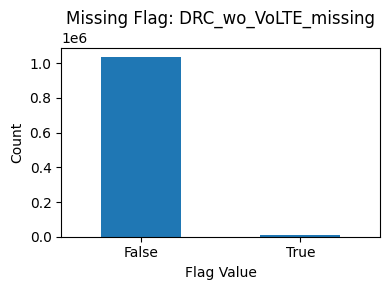

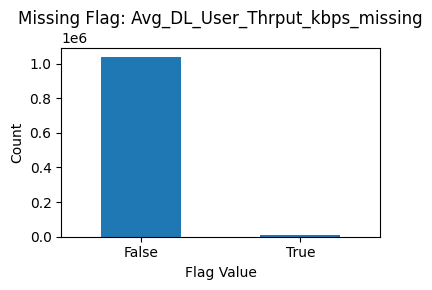

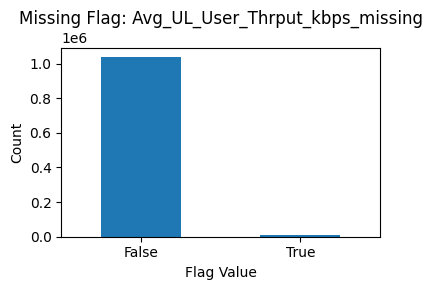

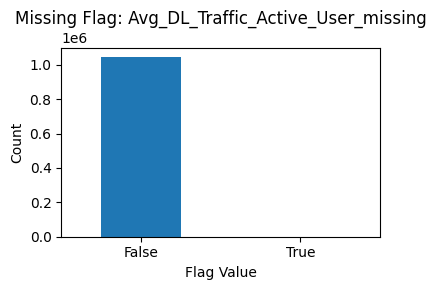

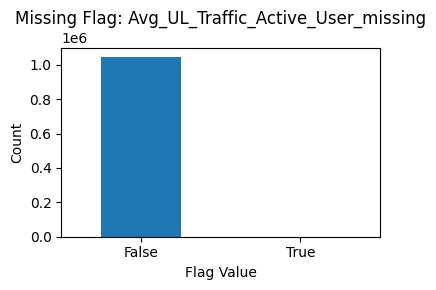

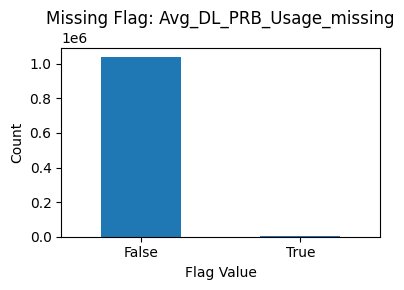

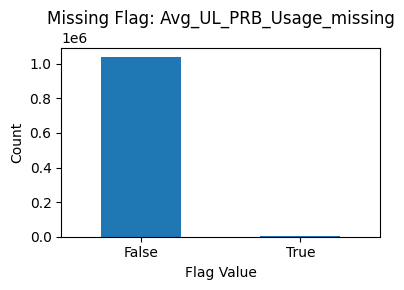

In [8]:
# Bar plots
for col in missing_flag_cols:
    plt.figure(figsize=(4, 3))
    df[col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f'Missing Flag: {col}')
    plt.xlabel('Flag Value')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

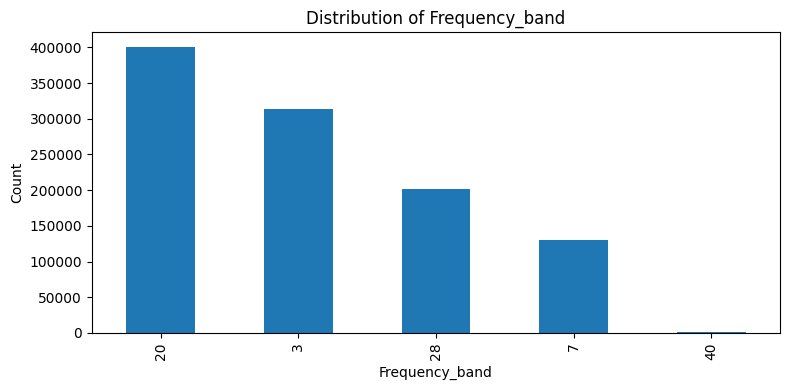

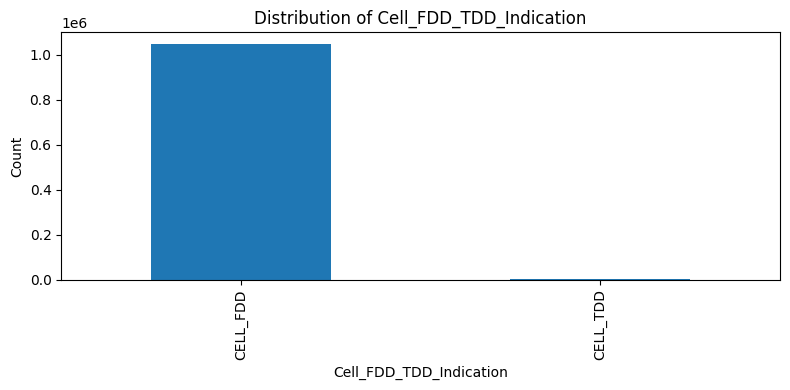

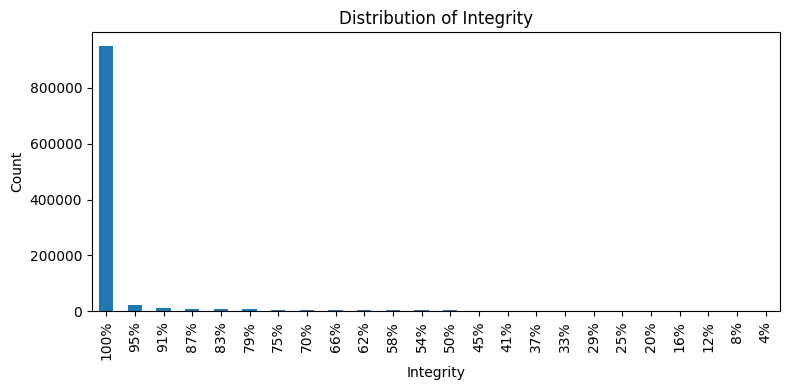

In [9]:
# Bar plots
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

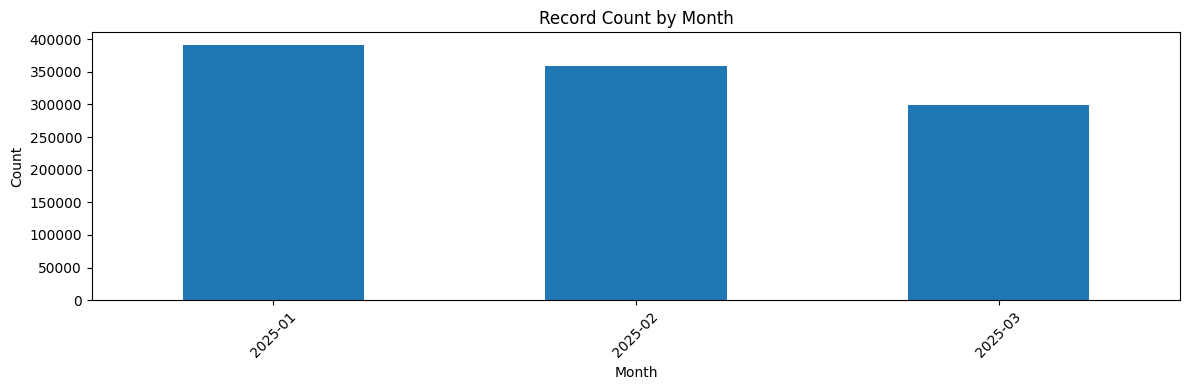

In [10]:
# Date summary
df['Date'].dt.to_period('M').value_counts().sort_index().plot(kind='bar', figsize=(12, 4))
plt.title('Record Count by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

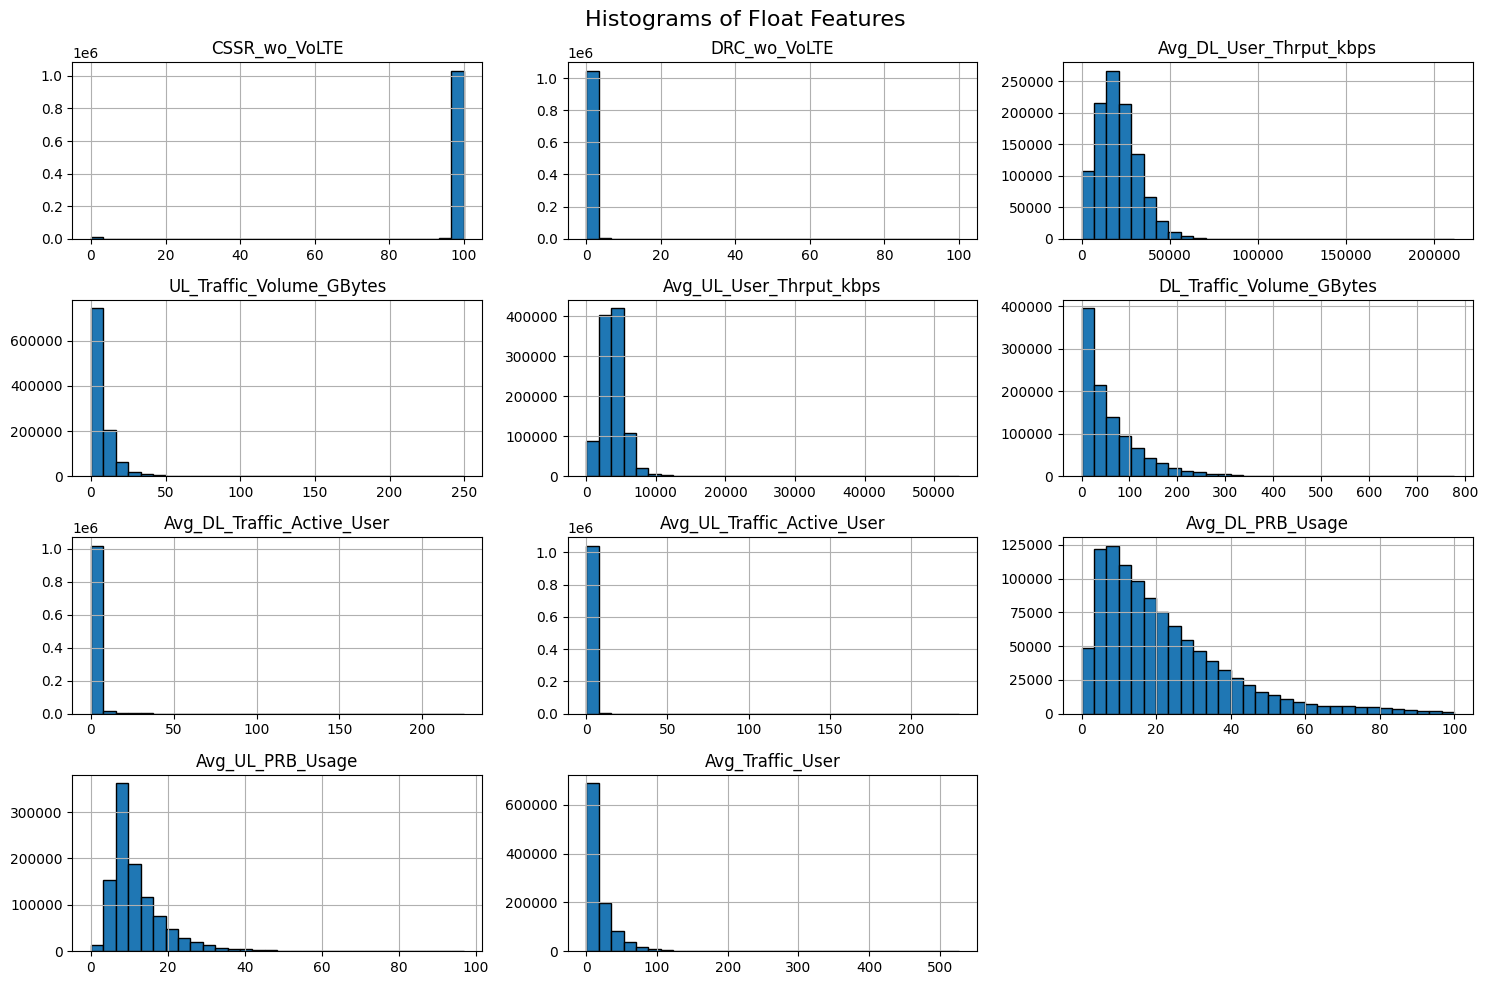

In [11]:
# Float columns histograms
df[numeric_cols].hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.suptitle('Histograms of Float Features', fontsize=16)
plt.tight_layout()
plt.show()

### Bivariate Analysis

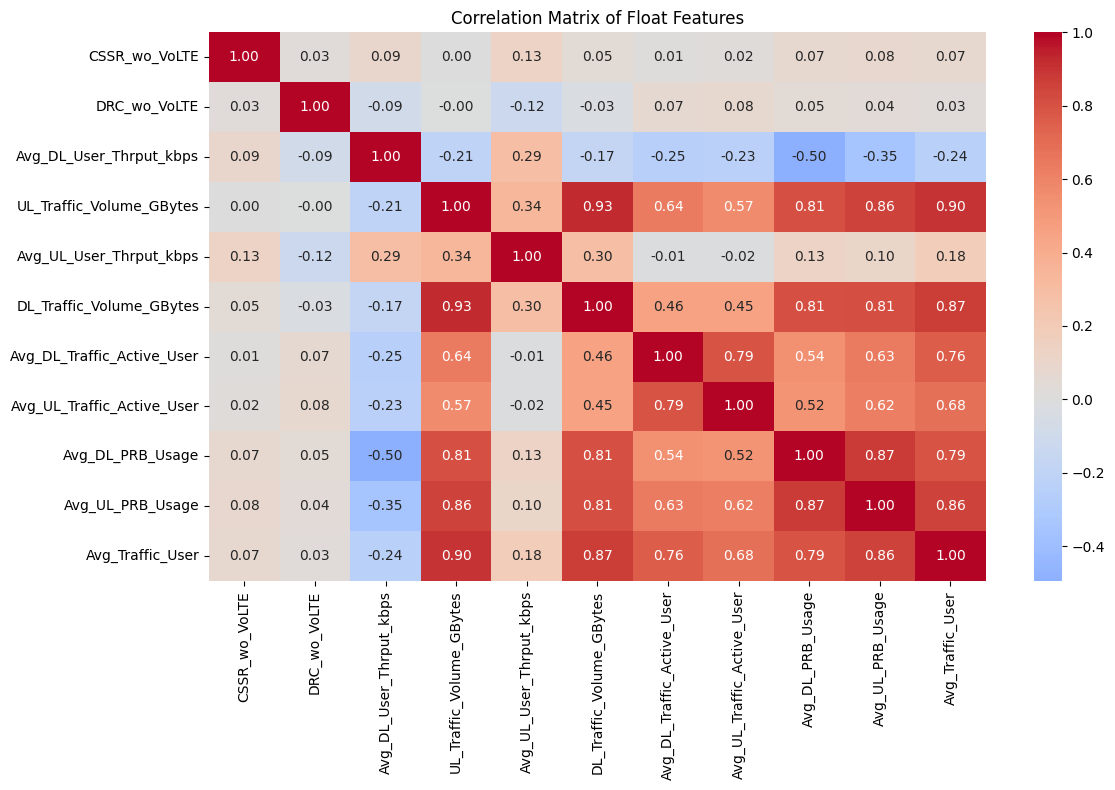

In [12]:
# Correlation Matrix
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Float Features')
plt.tight_layout()
plt.show()

### Dimensionality Reduction & Redundancy Checks

In [13]:
from sklearn.preprocessing import StandardScaler

# Scale the float features
X_numeric = df[numeric_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

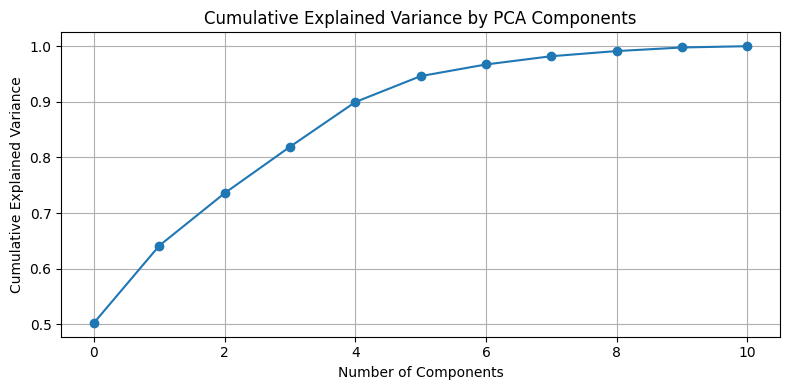

In [14]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(explained_var), marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()

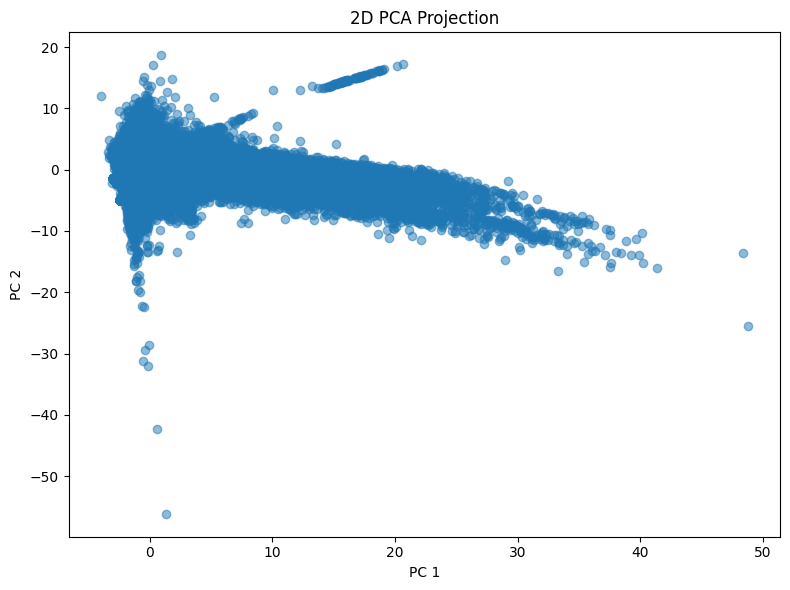

In [15]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.title('2D PCA Projection')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.utils import resample

def evaluate_clustering(X, labels):
    """
    Evaluate clustering performance using:
    - Silhouette Score
    - Davies-Bouldin Index
    - Calinski-Harabasz index
    """
    
    # Filter out noise points (e.g., from DBSCAN) if present
    if -1 in labels:
        X_valid = X[labels != -1]
        labels_valid = labels[labels != -1]
    else:
        X_valid = X
        labels_valid = labels

    results = {}

    silhouette_sample_size = 10000
    # Silhouette Score: compute on a sample
    try:
        X_sil, labels_sil = resample(X_valid, labels_valid, n_samples=silhouette_sample_size, random_state=42)
        results['Silhouette Score'] = silhouette_score(X_sil, labels_sil)
    except Exception as e:
        results['Silhouette Score'] = f"Error: {e}"

    try:
        results['Davies-Bouldin Index'] = davies_bouldin_score(X_valid, labels_valid)
    except Exception as e:
        results['Davies-Bouldin Index'] = f"Error: {e}"

    try:
        results['Calinski-Harabasz Index'] = calinski_harabasz_score(X_valid, labels_valid)
    except Exception as e:
        results['Calinski-Harabasz Index'] = f"Error: {e}"

    for metric, score in results.items():
        print(f"{metric}: {score}")

    return results

### K-Means

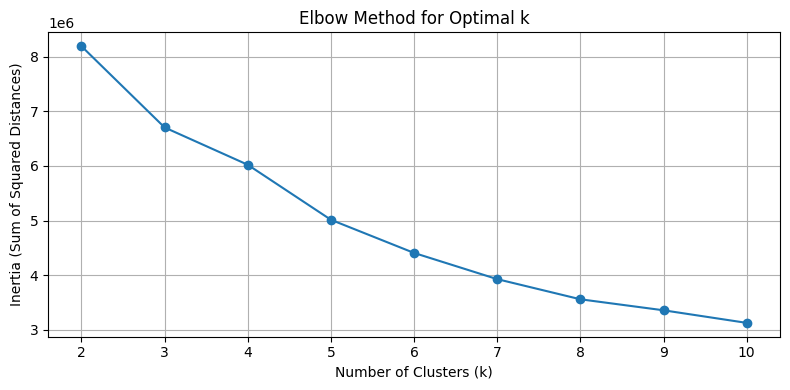

In [17]:
from sklearn.cluster import KMeans

# Elbow Method
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['cluster_kmeans'] = kmeans_labels

"""
Silhouette Score - Range: -1 to 1, The higher, the better
Davies-Bouldin Index - Range: >= 0, The lower, the better
Calinski-Harabasz Index - Range: >= 0, The higher, the better
"""
resullt = evaluate_clustering(X_scaled, kmeans_labels)

Silhouette Score: 0.2476462697967396
Davies-Bouldin Index: 1.0741507177385712
Calinski-Harabasz Index: 340714.09995594824


### GMM

In [19]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

df['cluster_gmm'] = gmm_labels

"""
Silhouette Score - Range: -1 to 1, The higher, the better
Davies-Bouldin Index - Range: >= 0, The lower, the better
Calinski-Harabasz Index - Range: >= 0, The higher, the better
"""
resullt = evaluate_clustering(X_scaled, gmm_labels)

Silhouette Score: 0.09514109720307551
Davies-Bouldin Index: 1.6588757570253185
Calinski-Harabasz Index: 165134.40886823775


### HDBSCAN

In [22]:
import hdbscan

hdbscan = hdbscan.HDBSCAN(min_cluster_size=500)
hdbscan_labels = hdbscan.fit_predict(X_scaled)

df['cluster_hdbscan'] = hdbscan_labels

"""
Silhouette Score - Range: -1 to 1, The higher, the better
Davies-Bouldin Index - Range: >= 0, The lower, the better
Calinski-Harabasz Index - Range: >= 0, The higher, the better
"""
result = evaluate_clustering(X_scaled, hdbscan_labels)

C:\Users\hkizamou\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\hkizamou\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Silhouette Score: 0.7087936025412539
Davies-Bouldin Index: 0.3942061748543424
Calinski-Harabasz Index: 69187.94210791607
